In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report
import seaborn as sns

In [2]:
np.random.seed(42)
X_dt0 = np.random.normal(loc=[30,40000], scale=[8,10000], size=(60,2))
y_dt0 = np.zeros(60)

X_dt1 = np.random.normal(loc=[50,70000], scale=[10,15000], size=(60,2))
y_dt1=np.ones(60)

X_dt=np.vstack((X_dt0,X_dt1))
y_dt=np.hstack((y_dt0, y_dt1))

df_dt = pd.DataFrame(X_dt, columns=['Age','Income'])
df_dt['Decision'] = y_dt

display(df_dt.head())

,Age,Income,Decision
0,33.973713,38617.356988,0.0
1,35.181508,55230.298564,0.0
2,28.126773,37658.630431,0.0
3,42.633703,47674.347292,0.0
4,26.244205,45425.600436,0.0


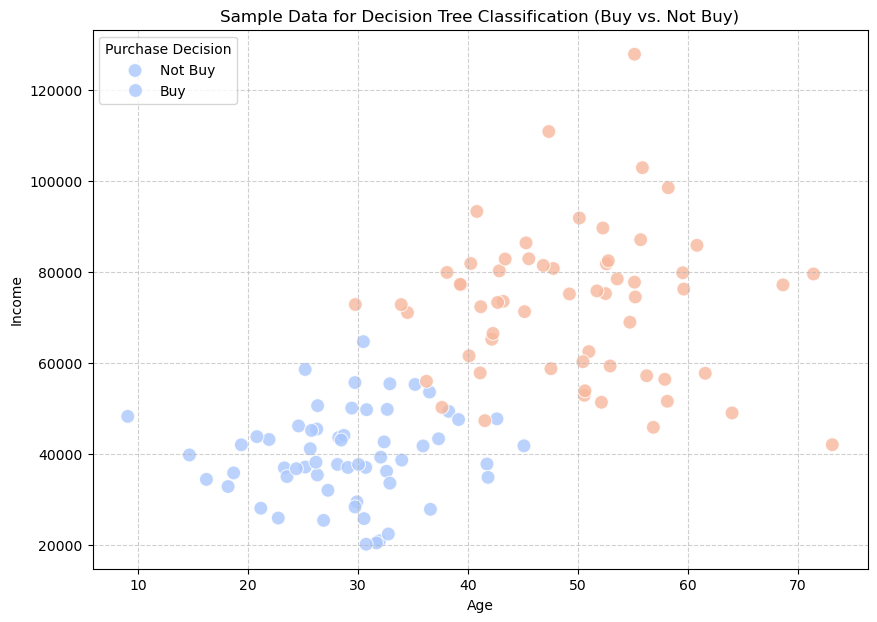

In [3]:
# Plot the generated data for Decision Tree
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age', y='Income', hue='Decision', data=df_dt, palette='coolwarm', s=100, alpha=0.8)
plt.title('Sample Data for Decision Tree Classification (Buy vs. Not Buy)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Purchase Decision', loc='upper left', labels=['Not Buy', 'Buy'])
plt.show()

In [4]:
# Split data for Decision Tree
X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(
    X_dt, y_dt, test_size=0.3, random_state=42
)

print(f"Training set shape for DT: {X_dt_train.shape}, {y_dt_train.shape}")
print(f"Testing set shape for DT: {X_dt_test.shape}, {y_dt_test.shape}")

Training set shape for DT: (84, 2), (84,)
Testing set shape for DT: (36, 2), (36,)


In [5]:
# Initialize Decision Tree classifier
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
dt_classifier.fit(X_dt_train, y_dt_train)

print("Decision Tree classifier trained successfully.")

Decision Tree classifier trained successfully.


In [6]:
# Make predictions on the test data
y_dt_pred = dt_classifier.predict(X_dt_test)

print("First 10 actual labels for DT:", y_dt_test[:10])
print("First 10 predicted labels for DT:", y_dt_pred[:10])

First 10 actual labels for DT: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
First 10 predicted labels for DT: [0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]


In [7]:
# Evaluate the Decision Tree model's performance
dt_accuracy = accuracy_score(y_dt_test, y_dt_pred)
dt_report = classification_report(y_dt_test, y_dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print("Decision Tree Classification Report:\n", dt_report)

Decision Tree Accuracy: 0.92
Decision Tree Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.89      0.92        19
         1.0       0.89      0.94      0.91        17

    accuracy                           0.92        36
   macro avg       0.92      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



In [8]:
#ACCURACY = TP+TN/TP+FP+FN+TN
#PRECISION = TP/TP+FP
#RECALL=TP/TP+FN
#F1 SCORE = 2*PRECISION*RECALL/PRECISION+RECALL
#SUPPORT=TP+FN(FOR POSITIVE CLASS ONLY)
#STANDARDIZATION Z=X-MU/SIGMA
from sklearn.tree import DecisionTreeClassifier, plot_tree



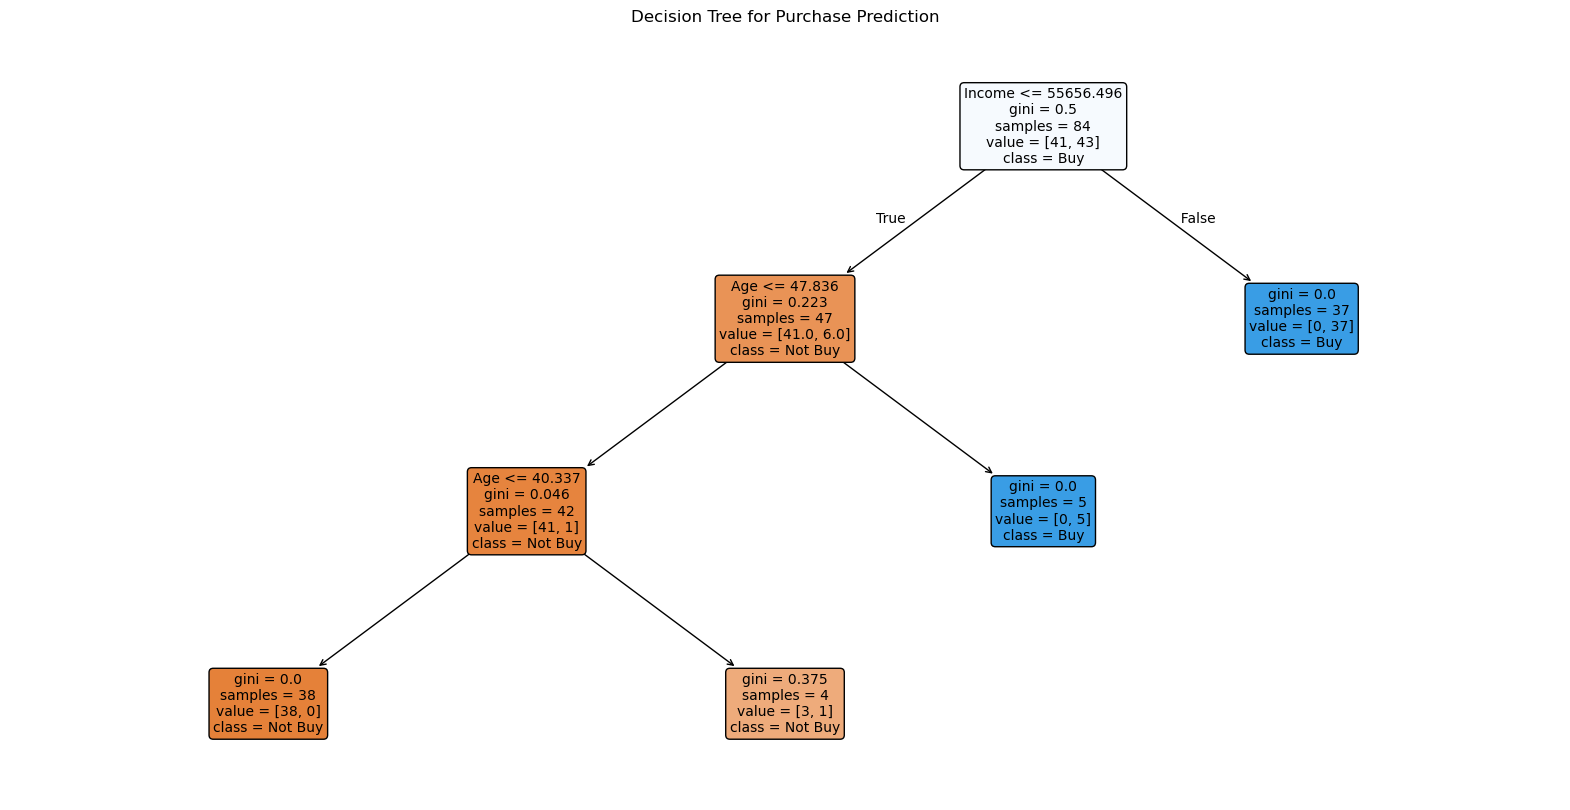

In [9]:
# Visualize the Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_classifier,
    feature_names=['Age', 'Income'],
    class_names=['Not Buy', 'Buy'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Purchase Prediction")
plt.show()